# JapanScope — Executive Dashboard

This notebook presents the 4 core findings of the JapanScope analysis 
in narrative order. Full methodology and supporting analysis available 
in notebooks 01-03.

**The story in one sentence:** Japan's GDP and stock market tell 
opposite stories about the same decade — and understanding why 
reveals which sectors, companies, and years actually benefited from 
a weakening yen.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    'figure.facecolor': 'white',

    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
})

annual = pd.read_csv("../data/processed/annual_enriched.csv")
recovery = pd.read_csv("../data/processed/recovery_scores.csv")

print(f"Annual enriched shape: {annual.shape}")
print(f"Columns: {annual.columns.tolist()}")
print(f"\nRecovery shape: {recovery.shape}")
print(f"Columns: {recovery.columns.tolist()}")

Annual enriched shape: (10, 10)
Columns: ['inflation_pct', 'gdp_usd', 'unemployment_pct', 'year', 'nikkei_avg_close', 'usd_jpy', 'boj_rate_pct', 'gdp_trillion', 'toyota_avg_close', 'sony_avg_close']

Recovery shape: (10, 8)
Columns: ['year', 'gdp_trillion', 'nikkei_avg_close', 'unemployment_pct', 'gdp_trillion_idx', 'nikkei_avg_close_idx', 'unemployment_pct_idx', 'recovery_score']


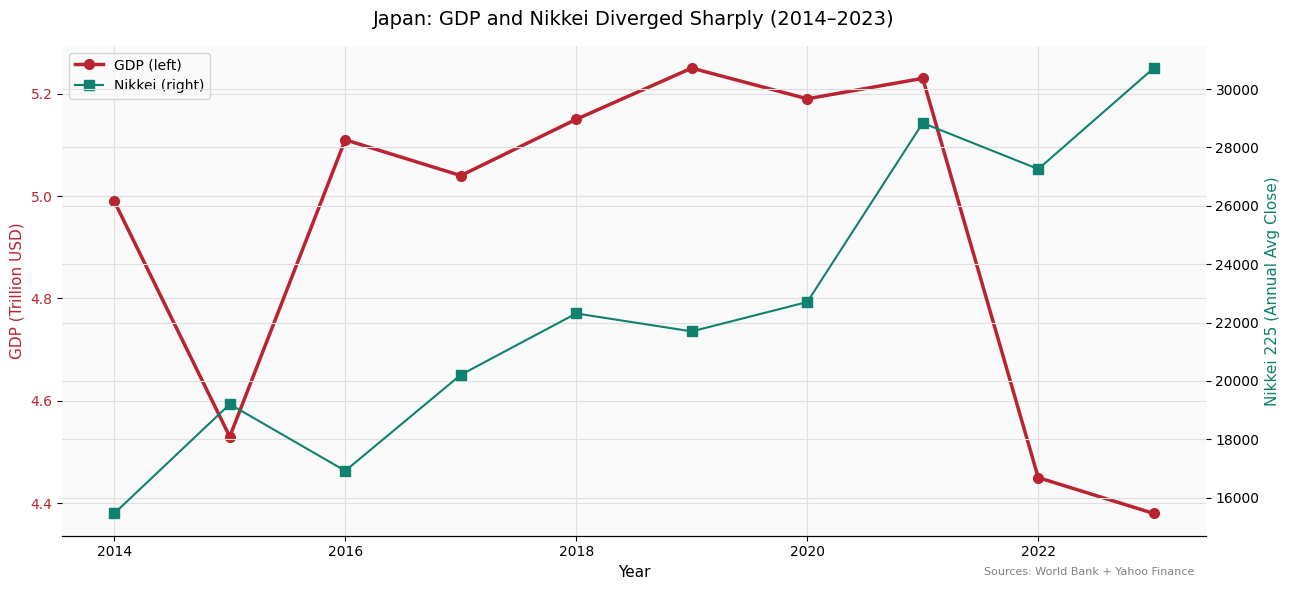

✓ Saved


In [3]:
fig, ax1 = plt.subplots(figsize=(13, 6))

color_gdp = "#BA2330"
ax1.plot(annual['year'], annual['gdp_trillion'],
         color=color_gdp, linewidth=2.5,
         marker='o', markersize=7, label='GDP (left)')
ax1.set_ylabel("GDP (Trillion USD)", color=color_gdp, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_gdp)


ax2 = ax1.twinx()
color_nikkei = "#0E826E"
ax2.plot(annual['year'], annual['nikkei_avg_close'],
         color=color_nikkei, marker='s', markersize=7, label='Nikkei (right)')
ax2.set_ylabel("Nikkei 225 (Annual Avg Close)",
               color=color_nikkei, fontsize=11)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, 
           fontsize=10, loc='upper left')

ax1.set_title("Japan: GDP and Nikkei Diverged Sharply (2014–2023)",
              fontsize=14, fontweight='500', pad=15)
ax1.set_xlabel("Year", fontsize=11)
ax1.text(0.99, -0.08, 'Sources: World Bank + Yahoo Finance',
         transform=ax1.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/dashboard_gdp_nikkei.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

The correlation between Japan's GDP and Nikkei 225 performance is 
-0.36, showing the two measures tended to move in opposite directions 
over 2014-2023. A weakening yen drives this split: it boosts yen-
denominated profits for export-heavy Nikkei companies like Toyota, 
while simultaneously raising the cost of energy imports that drag 
down GDP.

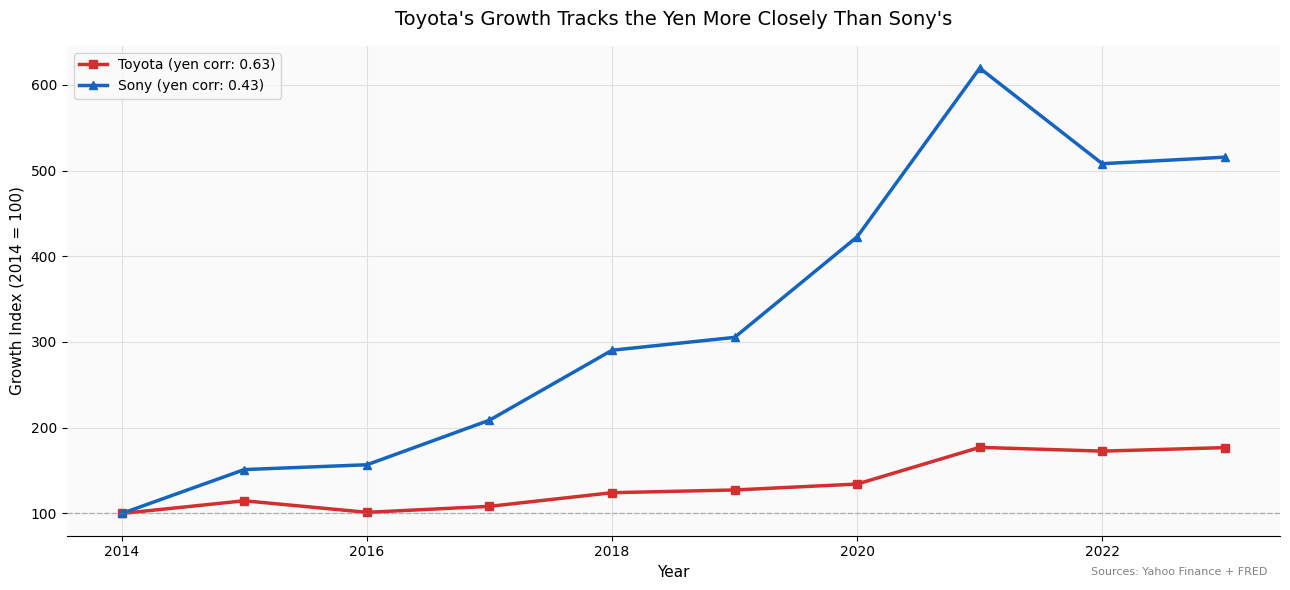

✓ Saved


In [4]:
base_year = 2014

multi_asset = annual[['year', 'nikkei_avg_close', 
                       'toyota_avg_close', 'sony_avg_close']].copy()

for col in ['nikkei_avg_close', 'toyota_avg_close', 'sony_avg_close']:
    base = multi_asset.loc[multi_asset['year'] == base_year, col].values[0]
    multi_asset[col + '_idx'] = (multi_asset[col] / base * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(multi_asset['year'], multi_asset['toyota_avg_close_idx'],
        color='#D32F2F', linewidth=2.5, marker='s', markersize=6,
        label='Toyota (yen corr: 0.63)')
ax.plot(multi_asset['year'], multi_asset['sony_avg_close_idx'],
        color='#1565C0', linewidth=2.5, marker='^', markersize=6,
        label='Sony (yen corr: 0.43)')

ax.axhline(y=100, color='gray', linewidth=1, linestyle='--', alpha=0.5)

ax.set_title("Toyota's Growth Tracks the Yen More Closely Than Sony's",
              fontsize=14, fontweight='500', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Growth Index (2014 = 100)", fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.text(0.99, -0.08, 'Sources: Yahoo Finance + FRED',
        transform=ax.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/dashboard_toyota_sony.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

Despite Toyota showing the stronger yen correlation (0.63 vs Sony's 
0.43), Sony's stock grew roughly 5x from its 2014 baseline while 
Toyota grew only 1.8x — correlation strength measures how sensitive 
a stock is to ONE specific variable, not how much the company actually 
grew overall.

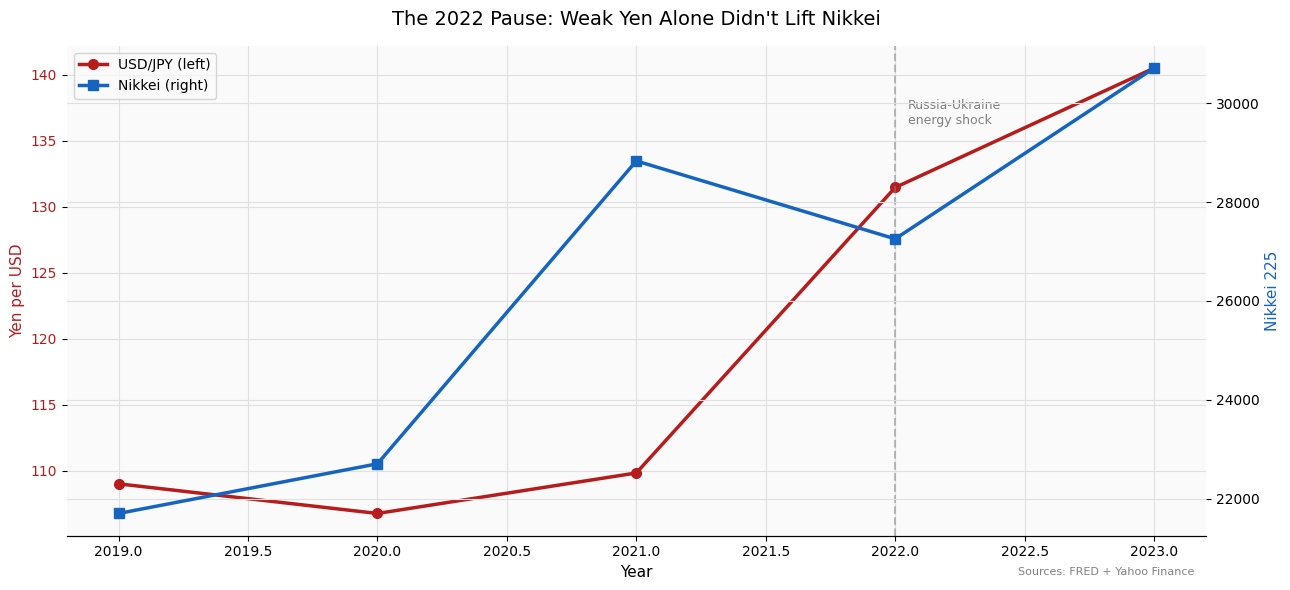

✓ Saved


In [5]:
# WHY show 3 metrics together on one chart:
# The chain finding involves BOJ rate -> yen -> inflation -> Nikkei.
# A single chart with all 3 key metrics (yen, inflation, Nikkei) 
# lets a reader see the 2022 dip and 2023 jump happen simultaneously 
# across all three, making the causal story visible at a glance

chain = annual[annual['year'].between(2019, 2023)].copy()

fig, ax1 = plt.subplots(figsize=(13, 6))

color_yen = '#B71C1C'
ax1.plot(chain['year'], chain['usd_jpy'],
         color=color_yen, linewidth=2.5, marker='o', markersize=7,
         label='USD/JPY (left)')
ax1.set_ylabel("Yen per USD", color=color_yen, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_yen)

ax2 = ax1.twinx()
color_nikkei = '#1565C0'
ax2.plot(chain['year'], chain['nikkei_avg_close'],
         color=color_nikkei, linewidth=2.5, marker='s', markersize=7,
         label='Nikkei (right)')
ax2.set_ylabel("Nikkei 225", color=color_nikkei, fontsize=11)

# WHY annotate Ukraine specifically:
# The chart alone would show yen weakening and Nikkei dipping 
# together in 2022 - looks contradictory without the annotation 
# explaining WHY the usual "weak yen boosts Nikkei" pattern paused

ax1.axvline(x=2022, color='gray', linestyle='--', alpha=0.5)
ax1.text(2022.05, chain['usd_jpy'].max()*0.97,
         'Russia-Ukraine\nenergy shock', fontsize=9, color='gray')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

ax1.set_title("The 2022 Pause: Weak Yen Alone Didn't Lift Nikkei",
              fontsize=14, fontweight='500', pad=15)
ax1.set_xlabel("Year", fontsize=11)
ax1.text(0.99, -0.08, 'Sources: FRED + Yahoo Finance',
         transform=ax1.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/dashboard_yen_chain.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

The weak yen's usual boost to Nikkei was temporarily interrupted in 
2022 by the Russia-Ukraine war, which triggered a global energy price 
shock and market-wide uncertainty that canceled out the weak-yen 
benefit for exporters — before the pattern reasserted itself in 2023. 
This shows that currency effects on stock markets can be overridden 
by larger geopolitical shocks, even when the underlying mechanism 
(weak yen boosting exporters) remains intact.

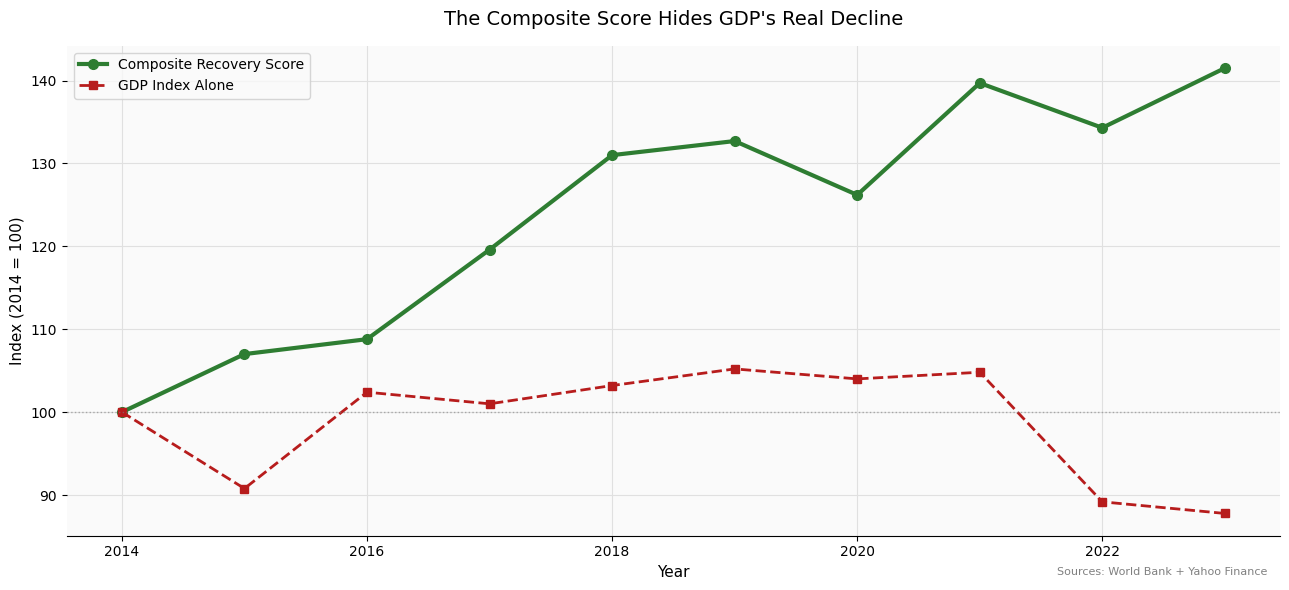

✓ Saved


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(recovery['year'], recovery['recovery_score'],
        color='#2E7D32', linewidth=3, marker='o', markersize=7,
        label='Composite Recovery Score')
ax.plot(recovery['year'], recovery['gdp_trillion_idx'],
        color='#B71C1C', linewidth=2, marker='s', markersize=6,
        linestyle='--', label='GDP Index Alone')

ax.axhline(y=100, color='gray', linewidth=1, linestyle=':', alpha=0.6)

ax.set_title("The Composite Score Hides GDP's Real Decline",
              fontsize=14, fontweight='500', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Index (2014 = 100)", fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.text(0.99, -0.08, 'Sources: World Bank + Yahoo Finance',
        transform=ax.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/dashboard_recovery_score.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved")

Japan's composite recovery score rose from 100 in 2014 to 141.5 by 
2023, suggesting strong overall economic recovery. However, this 
equal-weighted average conceals a critical detail: the GDP component 
alone fell to 87.8 by 2023
